# Workshop -- Module 2: In-situ Integration, Time Series and Anomaly Detection

**Mar Menor coastal lagoon -- PhD-level workshop, NYU**
*Duration: ~75 min*

---

## Learning objectives

By the end of this module you will be able to:

1. Access and harmonize **in-situ data** from the regional monitoring networks:
   - **CARM / IMIDA** (Murcia regional government oceanographic sondes)
   - **CHS-SAIH** (Segura watershed hydrology, river inflow, precipitation)
   - **Copernicus Marine Service In-Situ TAC (INS-TAC)**
   - **EMODnet** physical / chemistry portals
2. **Co-locate** satellite retrievals with in-situ measurements and quantify retrieval skill.
3. Build a **multivariate anomaly detector** for early-warning of eutrophication events.
4. Train a **supervised regressor** that learns to predict in-situ chl-a from Sentinel-2 reflectances.

## Where the in-situ data live

| Source | Variables | Latency | Access |
|---|---|---|---|
| **CARM Mar Menor** ([carm.es](https://canalmarmenor.carm.es/datos-en-tiempo-real/)) | T, S, chl-a, DO, turbidity from monitoring sondes | minutes to hours | Web portal + CSV download |
| **IMIDA** | agro-meteorological stations, soil moisture, nitrate proxies | daily | [SIAM](http://siam.imida.es/) |
| **CHS-SAIH** | precipitation, runoff, reservoir levels in the Segura basin | 15 min | [chsegura.es](https://www.chsegura.es/) |
| **Copernicus Marine INS-TAC** | global / Mediterranean in-situ obs (Argo, buoys, CTDs, gliders) | hours | `copernicus-marine` CLI / S3-compatible API |
| **EMODnet Chemistry / Physics** | aggregated EU coastal observations | weeks | OPeNDAP, WMS, WFS |
| **SOCIB / IEO** | regional moorings, research cruises | varies | THREDDS catalogues |

The cached buoy dataset for this module mimics the structure of the CARM portal exports.

In [1]:
# ── Dependency check (fail early with a clear message) ────────────────────
import importlib.util
_required = ["numpy", "pandas", "pyarrow", "xarray", "matplotlib", "sklearn", "scipy"]
_missing  = [p for p in _required if importlib.util.find_spec(p) is None]
if _missing:
    raise ImportError(
        "Missing packages: " + ", ".join(_missing) +
        "\nRun:  pip install -r requirements.txt"
    )

import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

DATA = Path("../data").resolve()

# ── Data sanity check ─────────────────────────────────────────────────────
EXPECTED = [
    "stations.csv",
    "insitu_buoys_2016_2025.parquet",
    "s2_sampling_points.csv",
    "sentinel2_waterquality.parquet",
    "watershed_forcing.csv",
]
missing = [f for f in EXPECTED if not (DATA / f).exists()]
if missing:
    raise FileNotFoundError(
        "Missing required data files:\n  " + "\n  ".join(missing) +
        "\nRun:  python scripts/generate_datasets.py"
    )
print("All required data files found.\n")

print("Files available:")
for f in sorted(DATA.iterdir()):
    print(f"  {f.name:42s}  {f.stat().st_size/1024:8.1f} KB")


All required data files found.

Files available:
  insitu_buoys_2016_2025.parquet                 249.7 KB
  insitu_buoys_sample.csv                          0.2 KB
  lagoon_contour_wgs84.npy                         3.1 KB
  s2_baseline_B02.tif                           5399.9 KB
  s2_baseline_B03.tif                           5490.9 KB
  s2_baseline_B04.tif                           4909.2 KB
  s2_baseline_B05.tif                           4223.0 KB
  s2_baseline_B08.tif                           3549.4 KB
  s2_baseline_TCI.tif                           8835.6 KB
  s2_bloom_B02.tif                              5476.1 KB
  s2_bloom_B03.tif                              5578.5 KB
  s2_bloom_B04.tif                              5603.7 KB
  s2_bloom_B05.tif                              5419.7 KB
  s2_bloom_B08.tif                              5529.4 KB
  s2_bloom_TCI.tif                              9355.1 KB
  s2_peak_B02.tif                               5322.7 KB
  s2_peak_B03.tif      

---
## 1. Loading the in-situ buoy network

The five stations roughly correspond to real CARM monitoring points around the lagoon perimeter.

In [2]:
stations = pd.read_csv(DATA / "stations.csv")
insitu   = pd.read_parquet(DATA / "insitu_buoys_2016_2025.parquet").assign(
    date=lambda d: pd.to_datetime(d["date"])
)
stations


,station_id,name,lon,lat,depth_m
0,MM01,Los Alcazares,-0.838,37.741,4.5
1,MM02,Los Urrutias,-0.823,37.685,6.2
2,MM03,El Estacio,-0.741,37.755,5.1
3,MM04,La Manga Sur,-0.728,37.640,3.8
4,MM05,Punta Brava,-0.793,37.715,5.7


In [3]:
print(f"In-situ data: {len(insitu):,} daily records over {insitu.date.nunique()} days, "
      f"{insitu.station_id.nunique()} stations.")
insitu.describe().T.round(2)


In-situ data: 18,265 daily records over 3653 days, 5 stations.


,count,mean,min,25%,50%,75%,max,std
date,18265,2020-12-31 00:00:00,2016-01-01 00:00:00,2018-07-02 00:00:00,2020-12-31 00:00:00,2023-07-02 00:00:00,2025-12-31 00:00:00,NaN
sst_C,18265.0,18.984723,7.44,12.29,18.99,25.68,30.26,6.743834
salinity_psu,18265.0,44.476603,39.25,44.08,44.49,44.9,46.99,0.653231
chla_mg_m3,18265.0,1.595479,0.05,0.793,1.276,2.128,12.504,1.222712
turbidity_FNU,18265.0,1.329725,0.1,0.445,1.106,1.975,8.509,1.086382
do_mg_L,18265.0,7.403807,1.77,6.9,7.42,7.93,9.48,0.731456
nitrate_mg_L,18265.0,0.850861,0.142,0.7,0.801,0.903,12.959,0.701612


### 1.1 Quick exploratory plot -- the August 2021 hypoxia crisis

Pull the daily DO at the most affected stations and overlay SST. This is what regional authorities saw in real time during the fish-kill event.

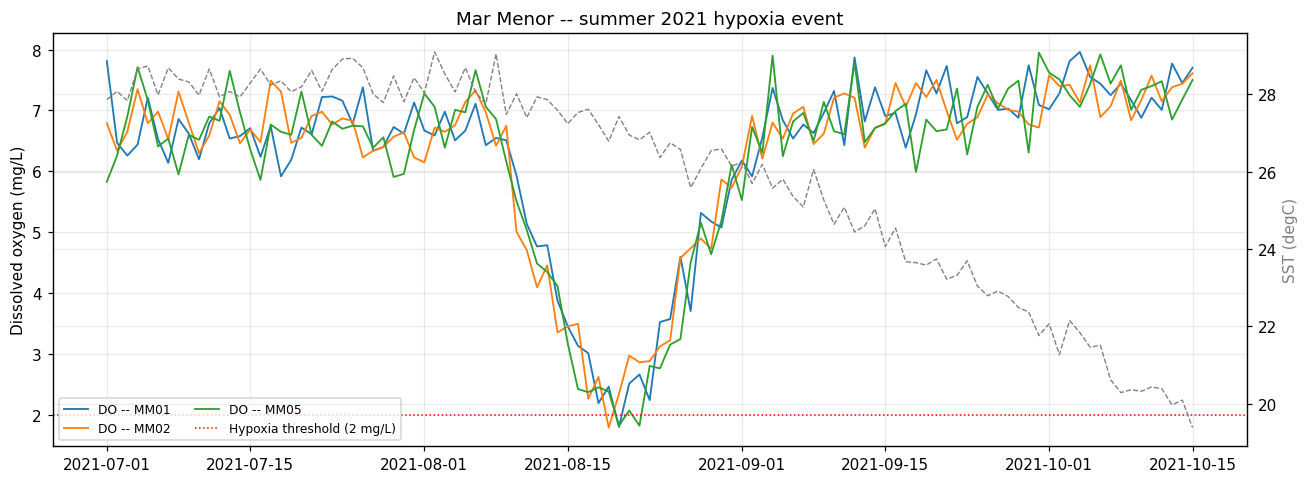

In [4]:
focus = insitu.query("station_id in ['MM01','MM02','MM05'] and "
                     "'2021-07-01' <= date <= '2021-10-15'")

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()

for stid, grp in focus.groupby("station_id"):
    ax1.plot(grp["date"], grp["do_mg_L"], label=f"DO -- {stid}", lw=1.2)
ax1.axhline(2.0, color="red", ls=":", lw=1, label="Hypoxia threshold (2 mg/L)")
ax1.set_ylabel("Dissolved oxygen (mg/L)")
ax1.set_xlabel("")
ax1.legend(loc="lower left", fontsize=8, ncol=2)

ax2.plot(focus.groupby("date")["sst_C"].mean(), color="grey", lw=0.9, ls="--", label="Mean SST")
ax2.set_ylabel("SST (degC)", color="grey")

ax1.set_title("Mar Menor -- summer 2021 hypoxia event")
fig.tight_layout(); plt.show()


### 1.2 The 2019 DANA -- nitrate pulse and salinity drop

DANA = *Depresión Aislada en Niveles Altos*; cut-off cold drops that produce extreme convective rainfall over SE Spain. The September 2019 episode dumped 300+ mm in 48 h over the Campo de Cartagena, sending a large freshwater + nitrate plume into the lagoon.

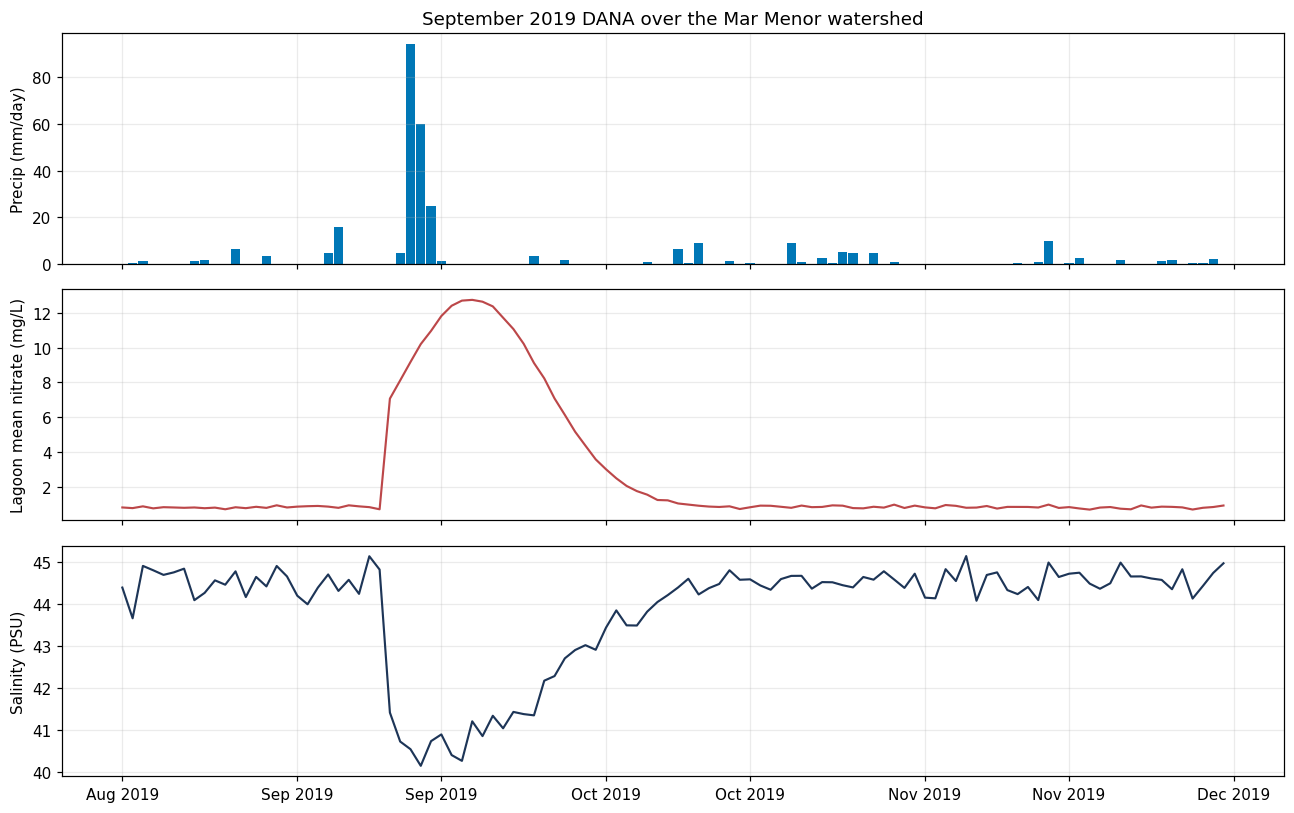

In [5]:
dana = insitu.query("'2019-08-15' <= date <= '2019-11-30'")
ws = pd.read_csv(DATA / "watershed_forcing.csv", parse_dates=["date"])
ws_dana = ws.query("'2019-08-15' <= date <= '2019-11-30'")

fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
axes[0].bar(ws_dana["date"], ws_dana["precip_mm"], color="#0077b6", width=0.9)
axes[0].set_ylabel("Precip (mm/day)")
axes[0].set_title("September 2019 DANA over the Mar Menor watershed")

mean_nit = dana.groupby("date")["nitrate_mg_L"].mean()
axes[1].plot(mean_nit.index, mean_nit.values, color="#bc4749", lw=1.4)
axes[1].set_ylabel("Lagoon mean nitrate (mg/L)")

mean_sal = dana.groupby("date")["salinity_psu"].mean()
axes[2].plot(mean_sal.index, mean_sal.values, color="#1d3557", lw=1.4)
axes[2].set_ylabel("Salinity (PSU)")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.tight_layout(); plt.show()


---
## 2. Match-ups: satellite vs in-situ

Validating any satellite retrieval requires **co-located** in-situ measurements. The de-facto rule is a 3 km / 3 h window for ocean colour. We'll use a slightly looser temporal window because our in-situ data are daily.

In [6]:
s2 = pd.read_parquet(DATA / "sentinel2_waterquality.parquet").assign(
    date=lambda d: pd.to_datetime(d["date"])
)
points = pd.read_csv(DATA / "s2_sampling_points.csv")

# Compute spatial distance from each S2 sampling point to each buoy
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371
    rlat1, rlat2 = np.radians(lat1), np.radians(lat2)
    dlat = rlat2 - rlat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(rlat1)*np.cos(rlat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

dist = []
for _, p in points.iterrows():
    for _, s in stations.iterrows():
        dist.append({"point_id": p.point_id, "station_id": s.station_id,
                     "d_km": haversine_km(p.lon, p.lat, s.lon, s.lat)})
dist = pd.DataFrame(dist)

# Each S2 point keeps its nearest buoy
nearest = (dist.sort_values("d_km")
              .drop_duplicates("point_id")
              .reset_index(drop=True))
print("Nearest buoy per S2 sampling point:")
nearest


Nearest buoy per S2 sampling point:


,point_id,station_id,d_km
0,S2_P08,MM03,0.324469
1,S2_P12,MM05,0.744640
2,S2_P11,MM02,0.870449
3,S2_P01,MM05,1.734514
4,S2_P04,MM03,2.554667
5,S2_P03,MM01,2.572323
6,S2_P09,MM02,2.810354
7,S2_P10,MM02,3.112927
8,S2_P06,MM05,3.243169
9,S2_P07,MM01,3.972684


In [7]:
# Match-up: same calendar day, nearest station
matchup = (
    s2.merge(nearest, on="point_id")
      .merge(insitu.rename(columns={"chla_mg_m3": "chla_insitu"}),
             on=["date", "station_id"])
      .query("d_km < 4.0")
      .rename(columns={"chla_mg_m3": "chla_satellite"})
      [["date", "point_id", "station_id", "d_km",
        "chla_satellite", "chla_insitu"]]
)
print(f"Match-ups within 4 km, same day: {len(matchup):,}")
matchup.head()


Match-ups within 4 km, same day: 4,050


,date,point_id,station_id,d_km,chla_satellite,chla_insitu
0,2017-01-01,S2_P01,MM05,1.734514,1.045,0.408
2,2017-01-01,S2_P03,MM01,2.572323,0.651,0.802
3,2017-01-01,S2_P04,MM03,2.554667,0.662,0.527
5,2017-01-01,S2_P06,MM05,3.243169,0.413,0.408
6,2017-01-01,S2_P07,MM01,3.972684,1.277,0.802


### 2.1 Retrieval skill -- scatter plot, regression and metrics

Standard skill metrics for ocean-colour retrievals are **Pearson r**, **bias**, **RMSE**, **MAE**, and **MAPE**. The log-transformed RMSE (RMSLE) is preferred because chl-a is approximately log-normally distributed.

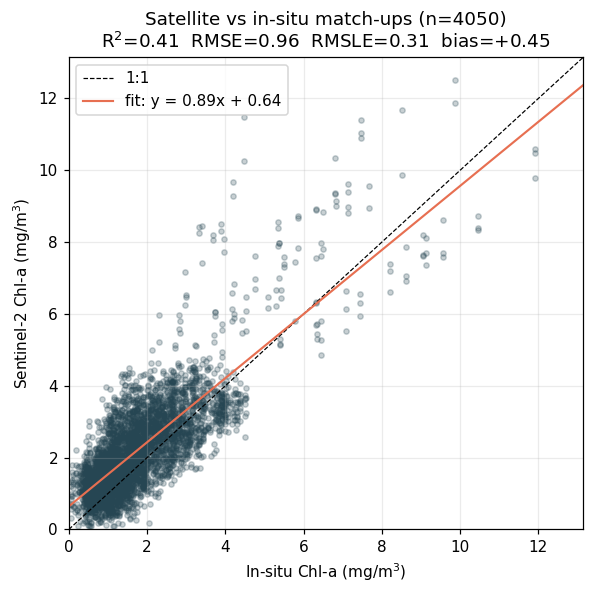

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

m = matchup.dropna()
x = m["chla_insitu"].values
y = m["chla_satellite"].values

bias = (y - x).mean()
rmse = np.sqrt(mean_squared_error(x, y))
rmsle = np.sqrt(mean_squared_error(np.log1p(x), np.log1p(y)))
r2   = r2_score(x, y)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(x, y, alpha=0.25, s=12, color="#264653")
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
# Linear fit
slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(0, lim, 50)
ax.plot(xx, slope*xx + intercept, color="#e76f51", lw=1.4,
        label=f"fit: y = {slope:.2f}x + {intercept:.2f}")
ax.set(xlim=(0, lim), ylim=(0, lim),
       xlabel="In-situ Chl-a (mg/m$^3$)",
       ylabel="Sentinel-2 Chl-a (mg/m$^3$)",
       title=(f"Satellite vs in-situ match-ups (n={len(m)})\n"
              f"R$^2$={r2:.2f}  RMSE={rmse:.2f}  RMSLE={rmsle:.2f}  bias={bias:+.2f}"))
ax.legend()
fig.tight_layout(); plt.show()


---
## 3. Machine learning: predicting chl-a from reflectances

A supervised regressor learns a non-linear mapping from S2 reflectances to in-situ chl-a, hopefully outperforming hand-tuned band ratios in extreme bloom regimes.

In [9]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

# Build features: 3 reflectance bands + band ratios + month-of-year + lat/lon
feat = (s2.merge(nearest, on="point_id")
          .merge(insitu.rename(columns={"chla_mg_m3": "chla_insitu"}),
                 on=["date", "station_id"])
          .merge(points, on="point_id"))

feat["NDCI"]   = (feat["Rrs_B05"] - feat["Rrs_B04"]) / (feat["Rrs_B05"] + feat["Rrs_B04"])
feat["B5_B4"]  = feat["Rrs_B05"] / feat["Rrs_B04"]
feat["month"]  = feat["date"].dt.month
feat["doy"]    = feat["date"].dt.dayofyear

FEATS = ["Rrs_B03", "Rrs_B04", "Rrs_B05", "NDCI", "B5_B4",
         "month", "doy", "lon", "lat"]
X = feat[FEATS].values
y = feat["chla_insitu"].values
print("Design matrix:", X.shape, " target range:", y.min().round(2), "-", y.max().round(2))


Design matrix: (4860, 9)  target range: 0.05 - 11.91


### 3.1 Time-series cross-validation

Because EO data are temporally autocorrelated, a random k-fold leaks information. We use `TimeSeriesSplit` which honours the chronological order.

In [10]:
feat_sorted = feat.sort_values("date").reset_index(drop=True)
X = feat_sorted[FEATS].values
y = feat_sorted["chla_insitu"].values

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []
for k, (tr, te) in enumerate(tscv.split(X), 1):
    model = GradientBoostingRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05, random_state=42)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[te])
    fold_metrics.append({
        "fold": k,
        "n_train": len(tr), "n_test": len(te),
        "MAE":   round(float(mean_absolute_error(y[te], pred)), 3),
        "RMSE":  round(float(np.sqrt(mean_squared_error(y[te], pred))), 3),
        "R2":    round(float(r2_score(y[te], pred)), 3),
    })
pd.DataFrame(fold_metrics)


,fold,n_train,n_test,MAE,RMSE,R2
0,1,810,810,0.555,1.278,0.403
1,2,1620,810,0.263,0.404,0.863
2,3,2430,810,0.294,0.435,0.937
3,4,3240,810,0.222,0.286,0.915
4,5,4050,810,0.401,0.579,0.638


### 3.2 Honest validation — predicting *unseen stations* (GroupKFold)

`TimeSeriesSplit` answers "can we predict future dates?" but the satellite and
in-situ values here share a common latent process, so temporal CV can look
optimistic. A harder, more honest test for an operational retrieval is **spatial
generalisation**: *can the model predict a station it has never seen?*

We use `GroupKFold` with the **station ID as the group**, so every fold holds out
entire stations. Expect lower R² than the temporal split — that gap is the
honest cost of deploying to a new, unmonitored location.

In [11]:
from sklearn.model_selection import GroupKFold

groups = feat_sorted["station_id"].values
n_groups = len(set(groups))
gkf = GroupKFold(n_splits=min(5, n_groups))   # one fold per held-out station
print(f"Spatial CV over {n_groups} distinct stations.")
rows = []
for k, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
    model = GradientBoostingRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05, random_state=42)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[te])
    rows.append({
        "fold": k,
        "heldout_stations": ",".join(sorted(set(groups[te]))),
        "n_test": len(te),
        "MAE":  round(float(mean_absolute_error(y[te], pred)), 3),
        "RMSE": round(float(np.sqrt(mean_squared_error(y[te], pred))), 3),
        "R2":   round(float(r2_score(y[te], pred)), 3),
    })
gkf_res = pd.DataFrame(rows)
print("Spatial CV (each fold predicts entirely held-out stations):")
print(f"  Mean R2  = {gkf_res['R2'].mean():.3f}  (vs temporal split above)")
print(f"  Mean MAE = {gkf_res['MAE'].mean():.3f} mg/m3")
gkf_res


Spatial CV over 4 distinct stations.


Spatial CV (each fold predicts entirely held-out stations):
  Mean R2  = 0.171  (vs temporal split above)
  Mean MAE = 0.689 mg/m3


,fold,heldout_stations,n_test,MAE,RMSE,R2
0,1,MM02,1620,0.813,1.062,0.481
1,2,MM05,1215,0.447,0.556,0.670
2,3,MM01,1215,0.759,0.904,0.447
3,4,MM03,810,0.735,0.875,-0.914


### 3.3 Final fit and feature importance

We refit on all data and inspect what the model is actually leaning on. In a real publication you would report SHAP values rather than impurity-based importances.

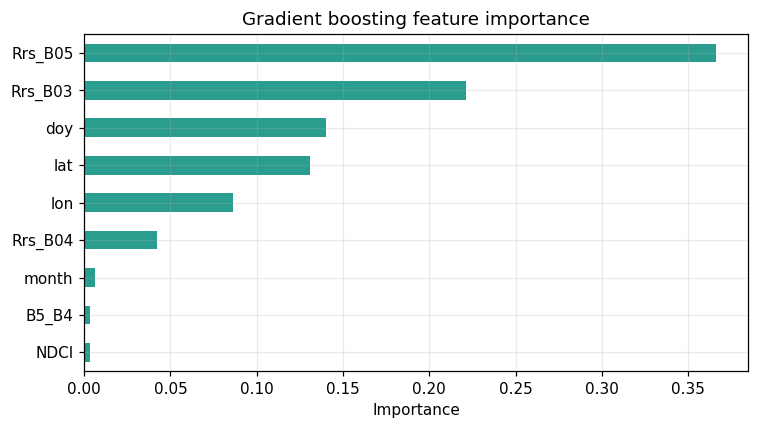

Top 3 features: ['Rrs_B05', 'Rrs_B03', 'doy']


In [12]:
model = GradientBoostingRegressor(
    n_estimators=600, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X, y)

imp = pd.Series(model.feature_importances_, index=FEATS).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(color="#2a9d8f", ax=ax)
ax.set(title="Gradient boosting feature importance", xlabel="Importance")
fig.tight_layout(); plt.show()

print("Top 3 features:", list(imp.tail(3).index[::-1]))


---
## 4. Multivariate anomaly detection

Eutrophication crises are characterized by **joint anomalies** across chl-a, turbidity, DO and SST. A univariate threshold (e.g. chl-a > 3 mg/m³) misses the precursors. We build a small Isolation Forest detector on lagoon-mean daily features.

> **Methodological point (early warning must not peek at the future).** If we fit
> the detector on the *whole* series — crises included — it learns the crises as
> "normal" and its scores are no longer an honest early-warning signal. For a
> defensible early-warning system we **fit only on the quiet pre-crisis years
> (2017–2018)** and then *apply* the frozen model to everything from 2019 on.
> What it flags after 2019 is genuinely out-of-sample.

In [13]:
from sklearn.ensemble import IsolationForest

daily = (insitu.groupby("date")[["sst_C", "salinity_psu",
                                  "chla_mg_m3", "turbidity_FNU",
                                  "do_mg_L", "nitrate_mg_L"]]
              .mean().reset_index())

# Smooth a bit to suppress measurement noise
sm = daily.copy()
FEATURES_ANOM = ["sst_C", "salinity_psu", "chla_mg_m3",
                 "turbidity_FNU", "do_mg_L", "nitrate_mg_L"]
sm[FEATURES_ANOM] = sm[FEATURES_ANOM].rolling(7, min_periods=1, center=True).mean()

# Fit ONLY on the quiet pre-crisis baseline (2017-2018), apply to the whole series
train = sm.query("date < '2019-01-01'")
iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
iso.fit(train[FEATURES_ANOM].values)

sm["score"]   = iso.decision_function(sm[FEATURES_ANOM].values)
sm["anomaly"] = iso.predict(sm[FEATURES_ANOM].values)   # -1 = anomaly

n_train = len(train)
post = sm.query("date >= '2019-01-01'")
n_anom = (post["anomaly"] == -1).sum()
print(f"Trained on {n_train} quiet days (2017-2018).")
print(f"Out-of-sample anomalies (>=2019): {n_anom} / {len(post)} "
      f"({100*n_anom/len(post):.1f}%)")


Trained on 1096 quiet days (2017-2018).
Out-of-sample anomalies (>=2019): 224 / 2557 (8.8%)


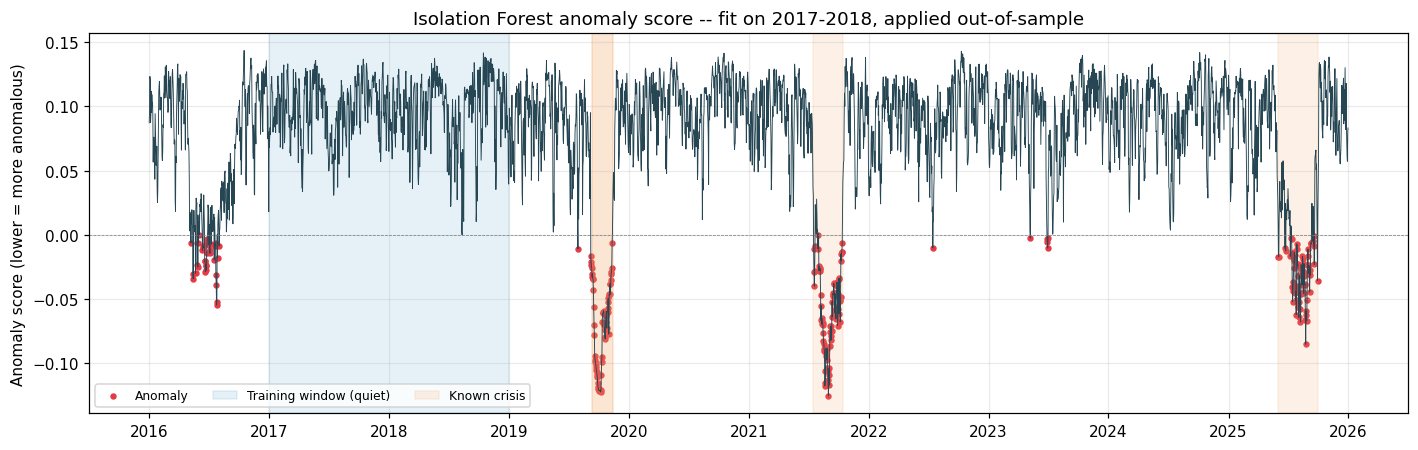

In [14]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(sm["date"], sm["score"], color="#264653", lw=0.6)
ax.scatter(sm.loc[sm["anomaly"] == -1, "date"],
           sm.loc[sm["anomaly"] == -1, "score"],
           color="#e63946", s=10, label="Anomaly")
ax.axhline(0, color="grey", lw=0.5, ls="--")

# Training window (quiet baseline) shaded in blue
ax.axvspan("2017-01-01", "2018-12-31", alpha=0.10, color="#0077b6",
           label="Training window (quiet)")

# Ground-truth crisis windows (note: 2016 is BEFORE the training data starts)
crises = [("2019-09-10", "2019-11-15"),
          ("2021-07-15", "2021-10-15"),
          ("2025-06-01", "2025-09-30")]
for s, e in crises:
    ax.axvspan(s, e, alpha=0.15, color="#f4a261")
ax.axvspan(crises[0][0], crises[0][1], alpha=0.15, color="#f4a261",
           label="Known crisis")

ax.set(title="Isolation Forest anomaly score -- fit on 2017-2018, applied out-of-sample",
       ylabel="Anomaly score (lower = more anomalous)")
ax.legend(loc="lower left", fontsize=8, ncol=3)
fig.tight_layout(); plt.show()


### 4.1 Lead time vs detection delay — two *different* metrics

A common mistake is to scan a window that starts *before* the event but ends
*after* it, take the first flag, and call it "lead time" — even when that flag
actually came **after** the crisis began. That conflates two opposite outcomes.
We separate them cleanly:

- **Lead time** = days the detector fires *before* the declared start. Only an
  anomaly inside `[start − N, start)` counts. This is the genuine early warning.
- **Detection delay** = if there was *no* pre-event flag, how many days *after*
  the start did it finally trigger. A positive delay means we missed the warning.

The agency cares about a positive **lead time**; a detection delay is a miss.

In [15]:
def first_pre_event_anomaly(start, days_before=60):
    """First flag strictly BEFORE the crisis start (the honest early warning)."""
    s = pd.Timestamp(start)
    win = sm[(sm["date"] >= s - pd.Timedelta(days=days_before)) & (sm["date"] < s)]
    flagged = win[win["anomaly"] == -1]
    return flagged["date"].iloc[0] if not flagged.empty else None

def first_in_event_anomaly(start, end):
    """First flag from the start onwards (used to measure detection delay)."""
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    win = sm[(sm["date"] >= s) & (sm["date"] <= e)]
    flagged = win[win["anomaly"] == -1]
    return flagged["date"].iloc[0] if not flagged.empty else None

rows = []
for s, e in crises:                     # 2019, 2021, 2025 (post-training)
    pre = first_pre_event_anomaly(s)
    if pre is not None:
        rows.append({"crisis_start": s, "first_flag": pre.date(),
                     "lead_days": (pd.Timestamp(s) - pre).days,
                     "detection_delay_days": 0, "outcome": "early warning"})
    else:
        ins = first_in_event_anomaly(s, e)
        if ins is not None:
            rows.append({"crisis_start": s, "first_flag": ins.date(),
                         "lead_days": 0,
                         "detection_delay_days": (ins - pd.Timestamp(s)).days,
                         "outcome": "late (caught after onset)"})
        else:
            rows.append({"crisis_start": s, "first_flag": None,
                         "lead_days": None, "detection_delay_days": None,
                         "outcome": "missed"})

lead_tbl = pd.DataFrame(rows)
print("Positive lead_days = genuine early warning; "
      "detection_delay_days > 0 = caught only after onset.")
lead_tbl


Positive lead_days = genuine early warning; detection_delay_days > 0 = caught only after onset.


,crisis_start,first_flag,lead_days,detection_delay_days,outcome
0,2019-09-10,2019-07-30,42,0,early warning
1,2021-07-15,2021-07-17,0,2,late (caught after onset)
2,2025-06-01,2025-06-02,0,1,late (caught after onset)


### 4.2 Exercise (~10 min)

**Q1.** Replace the Isolation Forest with a **Mahalanobis-distance** detector fitted on the *climatological* (non-crisis) days only. Compare:

- false-positive rate during 2017-2018 quiet years,
- lead time on the 2021 crisis,
- behaviour when you drop `do_mg_L` from the feature set (simulating a sensor failure).

What does the comparison tell you about robust monitoring under partial observability?

In [16]:
# --- Your solution here ---
# Reference solution sketch (uncomment to compare):
# from scipy.spatial.distance import mahalanobis
# from scipy.stats import chi2
# quiet = sm.query("'2017-04-01' <= date <= '2018-12-31'")
# mu = quiet[["sst_C","salinity_psu","chla_mg_m3","turbidity_FNU","do_mg_L","nitrate_mg_L"]].mean().values
# cov = np.cov(quiet[["sst_C","salinity_psu","chla_mg_m3","turbidity_FNU","do_mg_L","nitrate_mg_L"]].values.T)
# inv = np.linalg.inv(cov)
# def d2(row): return mahalanobis(row, mu, inv) ** 2
# sm["maha2"] = sm[["sst_C","salinity_psu","chla_mg_m3","turbidity_FNU","do_mg_L","nitrate_mg_L"]].apply(d2, axis=1)
# threshold = chi2.ppf(0.99, df=6)
# sm["maha_anom"] = (sm["maha2"] > threshold).astype(int)


---
## 5. Wrap-up and take-home tasks

We covered the full pipeline a coastal-monitoring analyst uses today:

1. **Discovery** of Sentinel imagery through CDSE STAC (`stac.dataspace.copernicus.eu/v1`, collection `sentinel-2-l2a`).
2. **Retrieval** of water-quality variables in Case-2 waters (C2RCC + empirical / ML) — remembering L2A reflectance is *not* itself an aquatic correction.
3. **Validation** against the in-situ CARM/IMIDA network, including spatial (unseen-station) generalisation.
4. **Anomaly detection** with an honest, out-of-sample early-warning protocol.

### Suggested take-home assignment

Extend the Isolation Forest to include the **watershed forcing** (`watershed_forcing.csv`: precipitation and nitrate flux) and quantify whether *prospective* (forecast precip) features further increase the lead time. This connects the EO pipeline back to the upstream agricultural processes that drive the lagoon's degradation.

### Further reading

- Brockmann, C. et al. (2016) -- *Evolution of the C2RCC neural network* (ESA SP-740).
- IOCCG Report 10 (2010) -- *Atmospheric correction for remotely-sensed ocean colour products*.
- Sentinel Hub custom evalscripts: https://custom-scripts.sentinel-hub.com/
- Copernicus Marine MyOcean toolbox (`pip install copernicus-marine`).

### Final discussion

> The Mar Menor degraded over decades but the *crisis events* are sub-monthly. EO + ML can shorten the loop from observation to action, but the underlying drivers (nitrate loading) are political. *What is the role of the scientist at that interface?*